#Домашнее задание. Решение конкурса на kaggle.com
Необходимо смоделировать отток клиентов телеком компании

##Загрузка данных (2 балла)
Посмотрим на таблицу с данными

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

%cd /content/drive/MyDrive/Colab Notebooks/Deep Learning (1 курс)/Занятия 15-16. Решающие деревья, композиции алгоритмов
data = pd.read_csv('./train.csv')
X_test = pd.read_csv('./test.csv')

data.sample(5)

/content/drive/MyDrive/Colab Notebooks/Deep Learning (1 курс)/Занятия 15-16. Решающие деревья, композиции алгоритмов


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
2141,17,34.40,592.75,Male,0,Yes,No,No,No phone service,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4367,4,20.95,85.5,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),1
1610,71,113.15,7953.25,Male,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),0
38,22,95.90,2234.95,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,Yes,Yes,No,Month-to-month,No,Credit card (automatic),0
4970,60,84.95,4984.85,Male,0,No,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,0


Теперь проверим есть ли в таблице пропущенные значения. Для этого воспользуемся pd.info(), которая выдаст количество строчек с not-null данными для каждого столбца (признака). Так как not-null - это np.NaN и None, хотелось бы дополнительно сменить все np.inf и пустые строки (whitespace) на None, но я следую по пунктам домашнего, поэтому сделаю это в следующем пункте.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

Как видим, в таблице нет пропущенных значений, так что пока что сходу что-то заменять или удалять не будем.

##Анализ данных (3 балла)
Посмотрим что из себя представляют данные в каждом столбике. Для этого посмотрим на уникальные значения.

In [4]:
for col in data:
  print(col, data[col].dtype, sorted(data[col].unique()))

ClientPeriod int64 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
MonthlySpending float64 [18.25, 18.4, 18.7, 18.8, 18.85, 18.9, 18.95, 19.0, 19.05, 19.1, 19.15, 19.2, 19.25, 19.3, 19.35, 19.4, 19.45, 19.5, 19.55, 19.6, 19.65, 19.7, 19.75, 19.8, 19.85, 19.9, 19.95, 20.0, 20.05, 20.1, 20.15, 20.2, 20.25, 20.3, 20.35, 20.4, 20.45, 20.5, 20.55, 20.6, 20.65, 20.7, 20.75, 20.8, 20.85, 20.9, 20.95, 21.0, 21.05, 21.1, 21.15, 21.2, 21.25, 21.3, 22.95, 23.15, 23.3, 23.4, 23.45, 23.5, 23.55, 23.65, 23.75, 23.8, 23.85, 23.9, 23.95, 24.0, 24.05, 24.1, 24.15, 24.2, 24.25, 24.3, 24.35, 24.4, 24.45, 24.5, 24.55, 24.6, 24.65, 24.7, 24.75, 24.8, 24.85, 24.9, 24.95, 25.0, 25.05, 25.1, 25.15, 25.2, 25.25, 25.3, 25.35, 25.4, 25.45, 25.5, 25.55, 25.6, 25.65, 25.7, 25.75, 25.

Первым делом замечаем, что TotalSpent содержит строки, а не числа, и вообще есть строки, содержащие пробел вместо числа. Посчитаем какие строки являются whitespace в этом столбце, и попробуем понять что с ними делать.

In [5]:
data[data['TotalSpent'].astype(str).str.fullmatch(r'\s*')]
#здесь все строки полностью (fullmatch) сравнивались с регулярным выражением,
#где \s - whitespace, а * - любое количество, в том числе 0

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


Всего 9 таких строк. Кажется, что их не много и можно было бы просто удалить их, но попробуем придумать какие значения можно там написать вместо пропусков.

Заметим, что все клиенты с пропущенным значением в TotalSpent имеют ClientPeriod = 0. Проверим правда ли не существует других ClientPeriod = 0 и при этом с заполенным TotalSpent.

In [6]:
len(data[data['ClientPeriod'] == 0 & data['TotalSpent'].astype(str).str.fullmatch(r'\s*')])

9

Значит ClientPeriod = 0 и незаполненный TotalSpent являются связанными случаями. Судя по названиям признаков, это клиенты, пользующиеся услугами компании 0 времени, значит и потратить они ничего не успели. Напишем им TotalSpent = 0 и сразу переведём строки в числа. Сделаем то же самое заодно и тестовой выборке X_test.

In [7]:
data.loc[data['TotalSpent'].astype(str).str.fullmatch(r'\s*'), 'TotalSpent'] = '0'
X_test.loc[X_test['TotalSpent'].astype(str).str.fullmatch(r'\s*'), 'TotalSpent'] = '0'
#без loc, т. е. data[data['TotalSpent']...] могли какие-то возникнуть ошибки из-за "цепного индексирования", при котором
#возвращается неизвестно что - оригинльный объект или его копия
data['TotalSpent'] = pd.to_numeric(data['TotalSpent']) #проблема без loc случается только при цепном индексировании (a['one']['two']), так что здесь всё ок (или я не до конца понял)
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'])

Теперь удалим дубликаты строчек.

In [8]:
print(data.duplicated().sum()) #считаем количество дубликатов без учёта первой строчки data[x0] = data[X1], где X1 - все дубликаты x0
data = data.drop_duplicates() #не удаляем первую строчку дубликатов (для иного см. документацию)
#Не удаляем дубликаты в тестовой выборке! Ведь надо будет сдавать ответы для всех изначальных строчек,
#мы пишем код не для продакшена

14


Теперь посмотрим на распределение целевой переменной.

In [9]:
print(data['Churn'].value_counts())

0    3894
1    1374
Name: Churn, dtype: int64


Как видим, доля ушедших клиентов составляет примерно четверть от общей. Датасет не сбалансирован, но не сильно, поэтому ничего с этим делать не будем. В связи с несбалансированностью, дальнейшие сравнительные относительно значения Churn графики будем строить для нормированных данных.

Теперь давайте построим гистограммы для числовых признаков.

0       1026.35
1       1872.20
2         75.90
3       2570.00
4       6758.45
         ...   
5277      82.15
5278    2188.45
5279      55.05
5280    2215.25
5281    1375.60
Name: TotalSpent, Length: 5268, dtype: float64


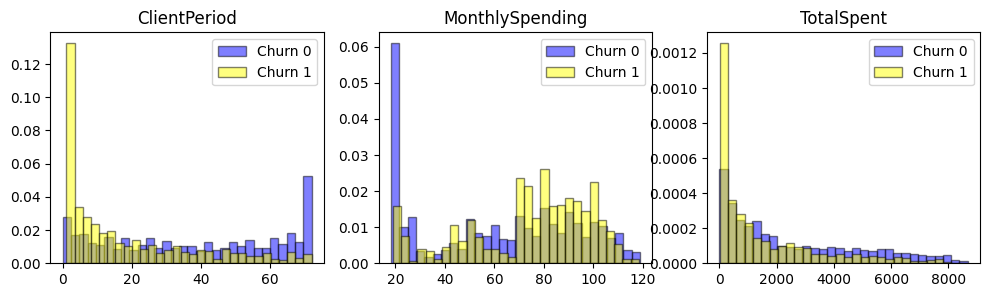

In [10]:
#Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

#Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

target_col = 'Churn'
print(data['TotalSpent'])

fig, axes = plt.subplots(figsize=[12, 3], nrows=1, ncols=3) #задаю поверхность 3 на 12, чтобы там разместить 3 в ряд графика размера 3:4
for i, col in enumerate(num_cols):
  #Строю гистограмму для колонки col среди таких строчек, где churn = 0. Гистограмма из 30 столбиков, типа barstacked (на одном графике несколько стоящих друг перед другом гистограмм).
  #Обозначаю метку label для легенды (без вызова plt.legend не появится на графике), задаю прозрачность alpha=0.5, нормализую данные (строю проценты, а не абсолютные значения)
  axes[i].hist(data[col][data['Churn'] == 0], bins=30, color='blue', edgecolor='black', histtype='barstacked', label='Churn 0', alpha=0.5, density=True)
  axes[i].hist(data[col][data['Churn'] == 1], bins=30, color='yellow', edgecolor='black', histtype='barstacked', label='Churn 1', alpha=0.5, density=True)
  axes[i].legend()
  axes[i].set_title(col)

plt.show()

Судя по графикам, в основном клиенты уходили почти сразу после становления клиентами. То есть, если попытаться как-то удержать клиентов в самом начале, вероятность их ухода сильно снижается.

Также видно, что есть некоторый диапазон ежемесячных трат, в котором находится большинство ушедших клиентов, и этот диапазон один с одними из самых больших трат за месяц. Вероятно, для удержания клиентов имеет смысл изначально не делать дорогие услуги. Видно, что и оставшиеся клиенты в основном тратят мало средств.

По третьему графику кажется сложно как-то судить, ведь логично, что раз большинство клиентов уходит почти сразу, всего они заплатят меньше. Меня это несколько наталкивает на какую-то корреляцию первого и третьего графиков, возможно у них есть какая-то линейная зависимость, хоть и последний столбик ClientPeriod это опровергает.

Далее по заданию от нас требуется вывести количество уникальных данных для категориальных столбцов и столбчатые графики. Чтобы проводить какое-то сравнение ушедших и оставшихся клиентов, будем делить количество каждого признака для churn=0 и churn=1 на общее количество.

Female    2621
Male      2647
Name: Sex, dtype: int64

0    4427
1     841
Name: IsSeniorCitizen, dtype: int64

No     2691
Yes    2577
Name: HasPartner, dtype: int64

No     3662
Yes    1606
Name: HasChild, dtype: int64

Yes    4747
No      521
Name: HasPhoneService, dtype: int64

No                  2497
No phone service     521
Yes                 2250
Name: HasMultiplePhoneNumbers, dtype: int64

DSL            1798
Fiber optic    2335
No             1135
Name: HasInternetService, dtype: int64

No                     2604
Yes                    1529
No internet service    1135
Name: HasOnlineSecurityService, dtype: int64

No                     2324
No internet service    1135
Yes                    1809
Name: HasOnlineBackup, dtype: int64

No                     2309
No internet service    1135
Yes                    1824
Name: HasDeviceProtection, dtype: int64

No                     2596
Yes                    1537
No internet service    1135
Name: HasTechSupportAccess, dtype: in

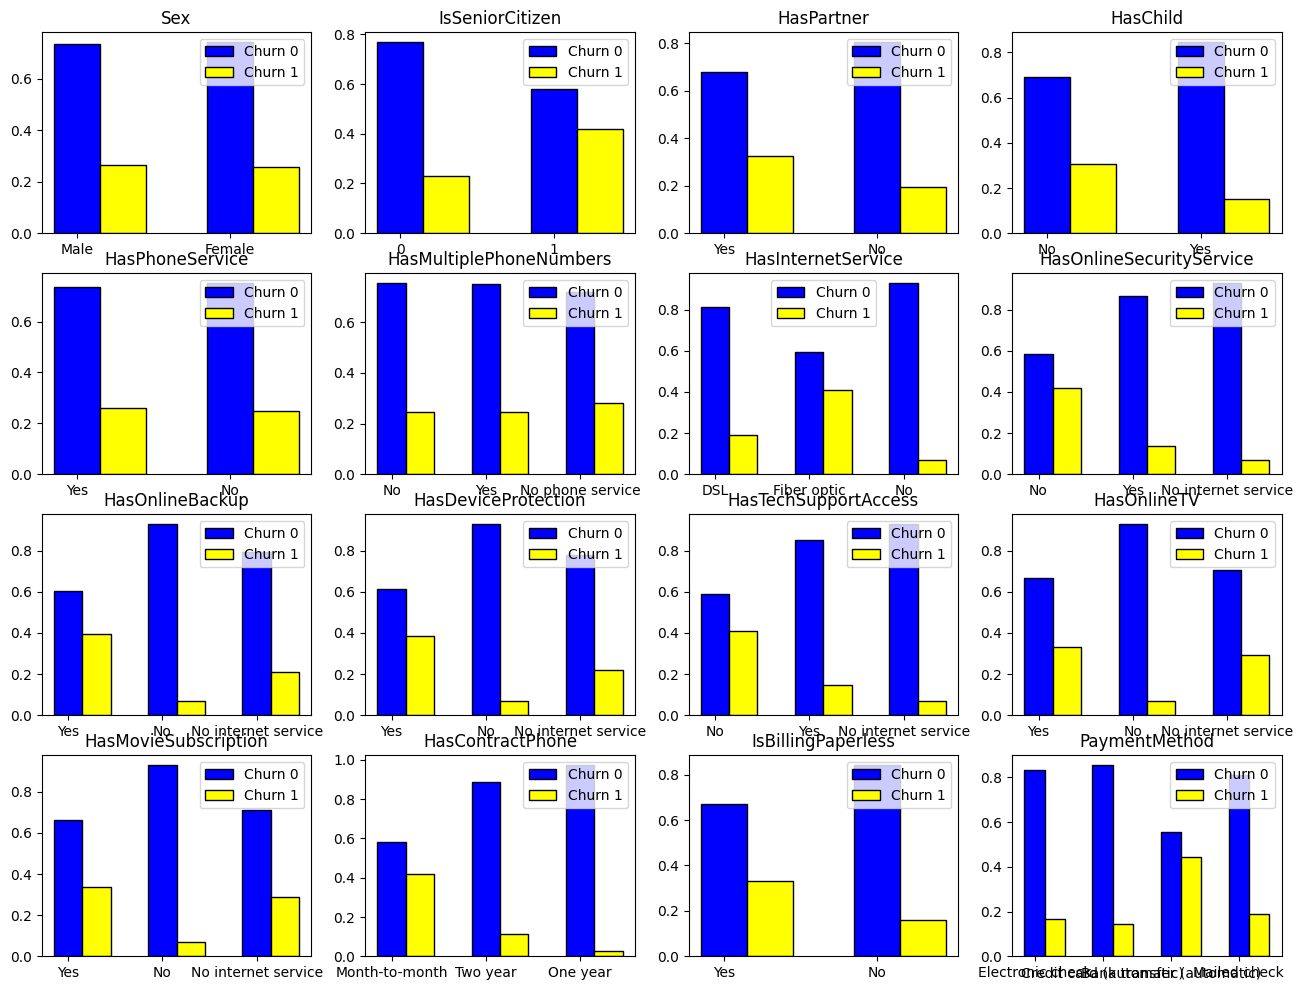

In [11]:
fig, axes = plt.subplots(figsize=[16, 12], nrows=4, ncols=4)
bar_width = 0.3

for num, col in enumerate(cat_cols):
  col_cnt_0 = data[col][data['Churn'] == 0].value_counts()
  col_cnt_1 = data[col][data['Churn'] == 1].value_counts()
  col_cnt = col_cnt_0 + col_cnt_1
  i, j = num // 4, num % 4
  axes[i, j].bar(np.arange(len(col_cnt_0)), col_cnt_0 / col_cnt, tick_label=col_cnt_0.index, color='blue', edgecolor='black', width=bar_width, label='Churn 0')
  axes[i, j].bar(np.arange(len(col_cnt_1)) + bar_width, col_cnt_1 / col_cnt, color='yellow', edgecolor='black', width=bar_width, label='Churn 1')
  axes[i, j].legend()
  axes[i, j].set_title(col)
  print(col_cnt, end='\n\n')

plt.show()

Среди значений признаков есть "No internet service" и "No phone service". Существуют и одноименные названия признаков, из чего можно предположить, что такие значения избыточны. Проверим это.

In [12]:
print('Count of \'No\' in HasPhoneService:', (data['HasPhoneService'] == 'No').sum())
print((data[cat_cols] == 'No phone service').sum(), end='\n\n')

print('Count of \'No\' in HasInternetService:', (data['HasInternetService'] == 'No').sum())
print((data[cat_cols] == 'No internet service').sum())

Count of 'No' in HasPhoneService: 521
Sex                           0
IsSeniorCitizen               0
HasPartner                    0
HasChild                      0
HasPhoneService               0
HasMultiplePhoneNumbers     521
HasInternetService            0
HasOnlineSecurityService      0
HasOnlineBackup               0
HasDeviceProtection           0
HasTechSupportAccess          0
HasOnlineTV                   0
HasMovieSubscription          0
HasContractPhone              0
IsBillingPaperless            0
PaymentMethod                 0
dtype: int64

Count of 'No' in HasInternetService: 1135
Sex                            0
IsSeniorCitizen                0
HasPartner                     0
HasChild                       0
HasPhoneService                0
HasMultiplePhoneNumbers        0
HasInternetService             0
HasOnlineSecurityService    1135
HasOnlineBackup             1135
HasDeviceProtection         1135
HasTechSupportAccess        1135
HasOnlineTV                 113

Действительно, количество значений "No phone service" и "No internet service" полностью совпадает с количеством ответов "No" в одноименных признаках. Так что будем считать такие значения эквивалентом значения "No".

In [13]:
cat_to_num = {
    "No": 0,
    "No internet service": 0, #значения "No", "No internet service" и
    "No phone service": 0, #"No phone service" превратятся в одно значение 0
    "Yes": 1,
    "Male": 0, #другие значения тоже могут становиться 0, так как не попадаются попадаются в тех же признаках, в которых значения могут быть "No..."
    "Female": 1,
    "DSL": 1,
    "Fiber optic": 2,
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2,
    "Credit card (automatic)": 0,
    "Bank transfer (automatic)": 1,
    "Mailed check": 2,
    "Electronic check": 3
}

X_train = data.replace(cat_to_num).drop(target_col, axis=1)
y_train = data[target_col]
X_test = X_test.replace(cat_to_num)

Отобразим дополнительно матрицу корреляций.

<Axes: >

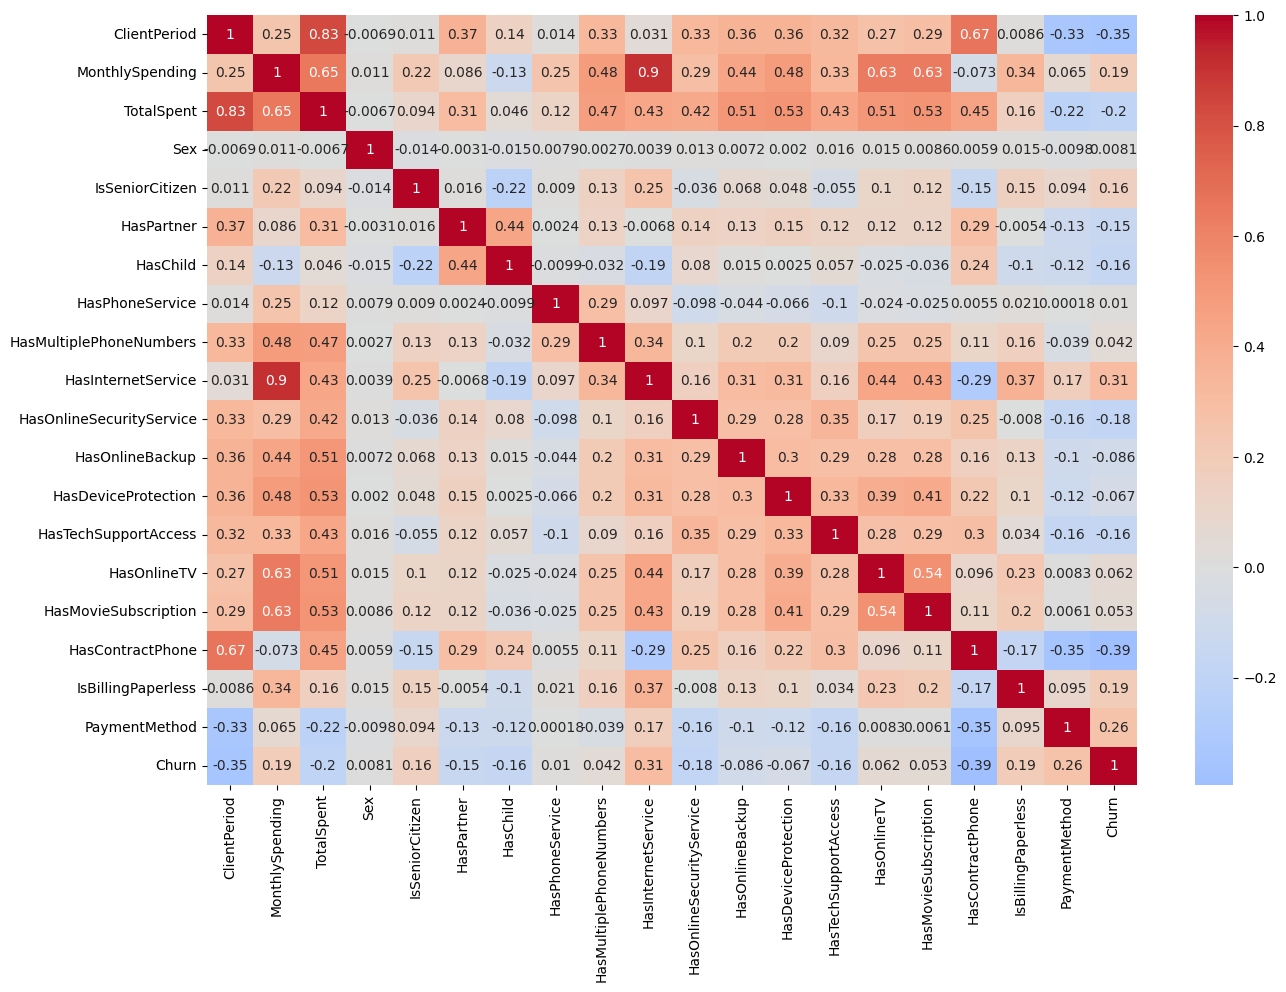

In [14]:
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap="coolwarm", center=0, ax=plt.subplots(figsize=(15,10))[1])

###Добавка после решения задания:

Здесь я не сделал никаких выводов. Надо бы сделать выводы какие признаки сильнее влияют (коррелируют) с целевым признаком. Так, HasInternetService имеет максимальную положительную корреляцию с Churn 0.31, а значит пользователи с этой услугой чаще уходят. А HasContractPhone имеют корреляцию -0.39, значит такие пользователи уходят реже.

Кроме того, те признаки, корреляция которых мала по модулю, почти не влияют на Churn, а значит их можно выкинуть. Я пока не знаю какая граница считается хорошей для выбрасывания признака, но явно бросаются в глаза Sex и HasPhoneService.

Еще я решил проверить что такое ClientPeriod. Предполагаю, что это количество месяцев. Чтобы убедиться в этом, поделю общие траты TotalSpent на траты в месяц MonthlySpending (должен получить траты в месяц) и вычту ClientPeriod.

In [21]:
diff_mean_spent_and_client_period = data['TotalSpent'] / data['MonthlySpending'] - data['ClientPeriod']
display(diff_mean_spent_and_client_period)
print("Mean difference:", diff_mean_spent_and_client_period.mean())
print("\nMost often value(s):")
display(diff_mean_spent_and_client_period.mode()) #это 0
print("It occurs", diff_mean_spent_and_client_period[diff_mean_spent_and_client_period == 0].count(), "times")

0      -2.366667
1       0.425532
2       0.000000
3       0.408575
4      -1.358351
          ...   
5277   -0.297697
5278   -0.766029
5279    0.000000
5280    0.148026
5281   -0.876153
Length: 5268, dtype: float64

Mean difference: -0.002867518543199654

Most often value(s):


0    0.0
dtype: float64

It occurs 453 times


По таблице видно, что не все значения 0, но большинство, и отклонения от этого значения не большие. Значит ClientPeriod скорее всего является количеством месяцев пользования, а отклонения - это либо какие-то акции на первые месяцы, либо разовые услуги вроде вызова мастера.

###Применение линейных моделей (3 балла)
Начнём с обучения с помощью логистической регрессии. Все категориальные признаки закодируем OneHotEncoder, а численные StandardScaler. С помощью кросс-валидации попробуем разные комбинации регуляризаций, гиперпараметров и СОЛВЕРОВ (что это?)

In [ ]:
%%time
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

SEED = 1
clf = make_pipeline(ColumnTransformer([('categorical', OneHotEncoder(), cat_cols), ('numerical', StandardScaler(), num_cols)]), LogisticRegression(max_iter=10000, random_state=SEED))
params_grid = {
    'logisticregression__penalty' : ['l1', 'l2', 'elasticnet'],
    'logisticregression__C': [100, 10, 1, 0.1, 0.01, 0.001],
    'logisticregression__solver': ['lbfgs', 'liblinear', 'newton-cg', 'saga'] #чё это?
}
grid_search = GridSearchCV(clf, params_grid, cv=5, scoring='roc_auc', n_jobs=-1, refit=True)

logreg = grid_search.fit(X_train, y_train)

print('best score:', logreg.best_score_)
print('best params:', logreg.best_params_)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 405, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)

best score: 0.8445579763151946
best params: {'logisticregression__C': 100, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
CPU times: user 2 s, sys: 151 ms, total: 2.15 s
Wall time: 53.3 s


Найдены лучшие параметры для модели.

##Применение градиентного бустинга (2 балла)
Используем CatBoost для улучшения результата

In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

X_ttrain, X_tvalid, y_ttrain, y_tvalid = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)
cb_clf = CatBoostClassifier()
cb_clf.fit(X_ttrain, y_ttrain, eval_set=(X_tvalid, y_tvalid), cat_features=cat_cols, verbose=0)

print(roc_auc_score(y_tvalid, cb_clf.predict_proba(X_tvalid)[:,1]))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 2.4 MB/s eta 0:00:00
0.8719858984846715


Осталось сделать предсказания для тестовой выборки на обоих классификаторах и сравнить результаты на kaggle.

In [ ]:
logreg_submission = pd.read_csv('./submission.csv')
logreg_submission['Churn'] = logreg.predict_proba(X_test)[:, 1]
logreg_submission.to_csv('./logreg_submission.csv')

catboost_submission = pd.read_csv('./submission.csv')
catboost_submission['Churn'] = cb_clf.predict_proba(X_test)[:, 1]
catboost_submission.to_csv('./catboost_submission.csv', index=False)

Результат логистической регрессии: 0.84591264583266

Результат катбуста: 0.8517693824128237